# PCA mit dem Iris-Datensatz
**Maschinelles Lernen mit Python · Kapitel 12: Dimensionsreduktion**  


---

## 🎯 Lernziele dieses Notebooks

Nach Bearbeitung dieses Notebooks können Sie:
- PCA auf einen realen 4D-Datensatz anwenden und auf 2D reduzieren
- einen **kumulierten Varianzplot** erstellen und die optimale Komponentenanzahl ablesen
- erklären, warum PCA die Klassenseparation verbessert, **obwohl keine Labels verwendet werden**
- den Unterschied zwischen Original-Scatterplot und PCA-Scatterplot kritisch beurteilen

---

## 📖 Kontext

Der **Iris-Datensatz** enthält 150 Blumenproben, beschrieben durch 4 Features (Kelch- und Blütenblattmaße). Wir reduzieren von **4D auf 2D** und vergleichen die Klassenseparation vor und nach der PCA.

> Iris-Datensatz: 150 Proben, 4 Features, 3 Klassen → 95,81% Varianz mit nur 2 Komponenten!

---
## Schritt 1: Iris-Datensatz laden und erkunden

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Iris-Datensatz laden
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print("Iris-Datensatz:")
print(f"  Stichproben: {X.shape[0]}")
print(f"  Features:    {X.shape[1]} → {feature_names}")
print(f"  Klassen:     {len(target_names)} → {list(target_names)}")
print(f"  Verteilung:  {np.bincount(y)} (je 50 Proben pro Klasse)")

import pandas as pd
df = pd.DataFrame(X, columns=feature_names)
df['Spezies'] = [target_names[i] for i in y]
print("\nStatistik (Mittelwerte pro Spezies):")
print(df.groupby('Spezies')[feature_names].mean().round(2))

Iris-Datensatz:
  Stichproben: 150
  Features:    4 → ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
  Klassen:     3 → [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
  Verteilung:  [50 50 50] (je 50 Proben pro Klasse)

Statistik (Mittelwerte pro Spezies):
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
Spezies                                                              
setosa                   5.01              3.43               1.46   
versicolor               5.94              2.77               4.26   
virginica                6.59              2.97               5.55   

            petal width (cm)  
Spezies                       
setosa                  0.25  
versicolor              1.33  
virginica               2.03  


---
## Schritt 2: Standardisierung und PCA

**Wichtig:** PCA ist varianzgetrieben. Da die Features unterschiedliche Größen haben (cm), muss standardisiert werden.

In [2]:
# Standardisierung
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# PCA auf 2 Komponenten
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

print("Erklärte Varianz pro Hauptkomponente:")
for i, var in enumerate(pca.explained_variance_ratio_, start=1):
    bar = '█' * int(var * 50)
    print(f"  PC{i}: {var*100:5.2f}%  {bar}")
print(f"\n  Kumuliert (PC1 + PC2): {np.sum(pca.explained_variance_ratio_)*100:.2f}%")
print(f"  → Nur 2 von 4 Dimensionen erklären {np.sum(pca.explained_variance_ratio_)*100:.1f}% der Information!")
print()
print("Ladungen (wie stark tragen originale Features zu den PCs bei?):")
loadings = pd.DataFrame(
    pca.components_.T,
    index=[f.replace(' (cm)', '') for f in feature_names],
    columns=['PC1', 'PC2']
).round(3)
print(loadings)

Erklärte Varianz pro Hauptkomponente:
  PC1: 72.96%  ████████████████████████████████████
  PC2: 22.85%  ███████████

  Kumuliert (PC1 + PC2): 95.81%
  → Nur 2 von 4 Dimensionen erklären 95.8% der Information!

Ladungen (wie stark tragen originale Features zu den PCs bei?):
                PC1    PC2
sepal length  0.521  0.377
sepal width  -0.269  0.923
petal length  0.580  0.024
petal width   0.565  0.067


---
## Schritt 3: Kumulierter Varianzplot – optimale Komponentenanzahl

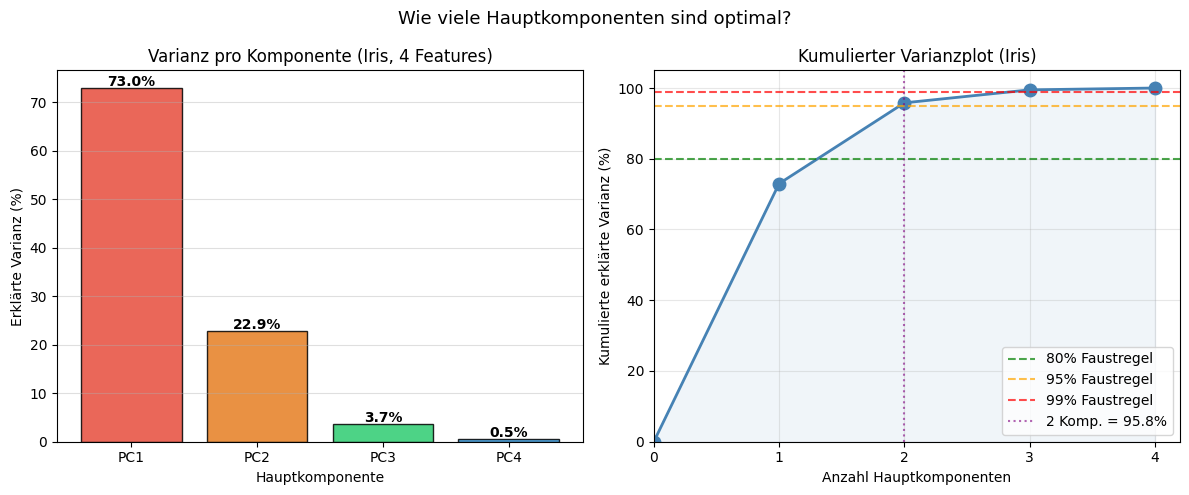

Mit 2 Komponenten: 95.81% Varianz erhalten – ausreichend für Visualisierung!
Mit 3 Komponenten: 99.48% Varianz erhalten


In [7]:
# Vollständige PCA für Varianzanalyse
pca_full = PCA()
pca_full.fit(X_std)

n_components = range(1, len(pca_full.explained_variance_ratio_) + 1)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db']
ax1.bar(n_components, pca_full.explained_variance_ratio_ * 100,
        color=colors, edgecolor='black', alpha=0.85)
ax1.set_xlabel('Hauptkomponente')
ax1.set_ylabel('Erklärte Varianz (%)')
ax1.set_title('Varianz pro Komponente (Iris, 4 Features)')
ax1.set_xticks(list(n_components))
ax1.set_xticklabels(['PC1', 'PC2', 'PC3', 'PC4'])
for i, v in enumerate(pca_full.explained_variance_ratio_ * 100):
    ax1.text(i+1, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')
ax1.grid(True, axis='y', alpha=0.4)

# Kumulierter Varianzplot
ax2.plot([0] + list(n_components), [0] + list(cumsum * 100), 'o-',
         color='steelblue', linewidth=2, markersize=9)
ax2.axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80% Faustregel')
ax2.axhline(y=95, color='orange', linestyle='--', alpha=0.7, label='95% Faustregel')
ax2.axhline(y=99, color='red', linestyle='--', alpha=0.7, label='99% Faustregel')

# Punkt für 2 Komponenten markieren
ax2.axvline(x=2, color='purple', linestyle=':', alpha=0.6, label=f'2 Komp. = {cumsum[1]*100:.1f}%')
ax2.fill_between([0] + list(n_components), [0] + list(cumsum * 100), alpha=0.08, color='steelblue')

ax2.set_xlabel('Anzahl Hauptkomponenten')
ax2.set_ylabel('Kumulierte erklärte Varianz (%)')
ax2.set_title('Kumulierter Varianzplot (Iris)')
ax2.set_xlim(0, 4.2)
ax2.set_ylim(0, 105)
ax2.set_xticks([0, 1, 2, 3, 4])
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.suptitle('Wie viele Hauptkomponenten sind optimal?', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Mit 2 Komponenten: {cumsum[1]*100:.2f}% Varianz erhalten – ausreichend für Visualisierung!")
print(f"Mit 3 Komponenten: {cumsum[2]*100:.2f}% Varianz erhalten")

---
## Schritt 4: Vorher/Nachher-Vergleich – Original vs. PCA-Scatterplot

**Kernfrage:** Warum verbessert PCA die Klassenseparation, obwohl keine Labels verwendet werden?

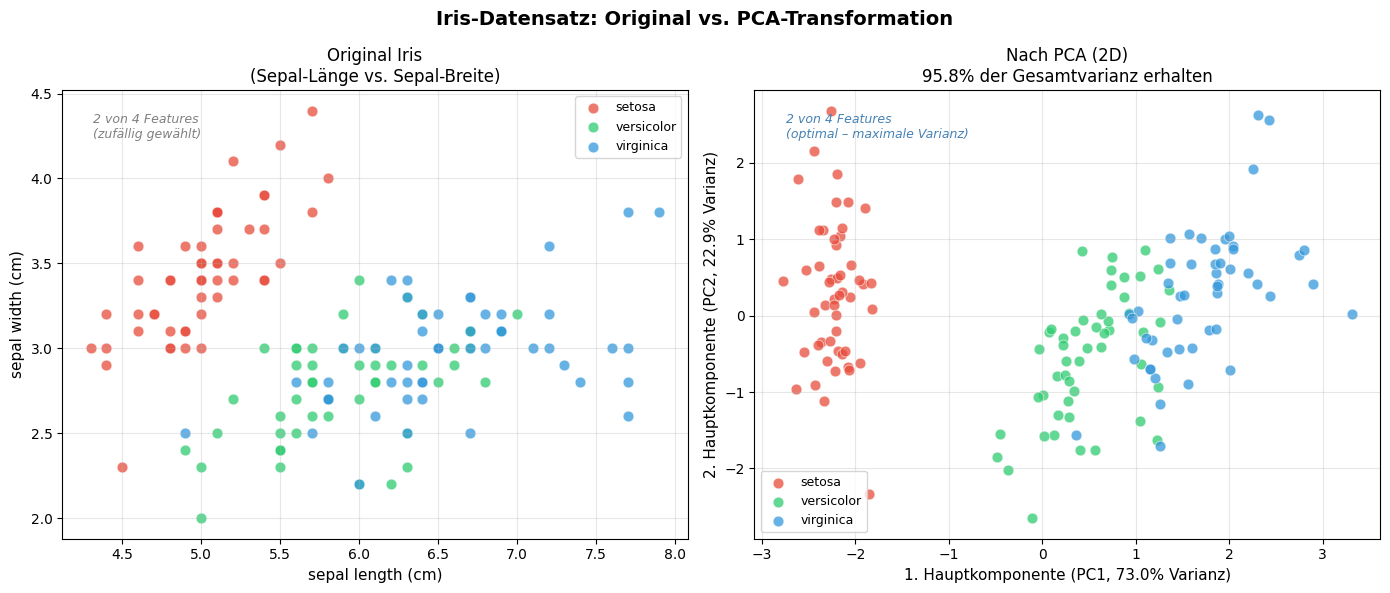

Vergleich:
  Original:  Versicolor (grün) und Virginica (blau) stark überlappend
  Nach PCA:  Deutlich bessere Trennung aller 3 Klassen

Warum?
  PCA wählt die 2 Richtungen mit der GRÖSSTEN Varianz aus ALLEN 4 Features.
  Das Vorher-Beispiel zeigte nur Sepal-Länge und Sepal-Breite –
  die Blütenblatt-Features (Petal) enthalten viel mehr Klasseninformation!


In [4]:
colors = ['#e74c3c', '#2ecc71', '#3498db']  # rot, grün, blau

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Original Iris (Sepal-Länge vs. Sepal-Breite) ---
for label, color, name in zip([0, 1, 2], colors, target_names):
    axes[0].scatter(X[y == label, 0], X[y == label, 1],
                    label=name, color=color, alpha=0.75, s=60, edgecolors='white', linewidth=0.5)

axes[0].set_xlabel(feature_names[0], fontsize=11)
axes[0].set_ylabel(feature_names[1], fontsize=11)
axes[0].set_title('Original Iris\n(Sepal-Länge vs. Sepal-Breite)', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].text(0.05, 0.95, '2 von 4 Features\n(zufällig gewählt)',
             transform=axes[0].transAxes, fontsize=9,
             verticalalignment='top', style='italic', color='gray')

# --- Plot 2: PCA (PC1 vs. PC2) ---
for label, color, name in zip([0, 1, 2], colors, target_names):
    axes[1].scatter(X_pca[y == label, 0], X_pca[y == label, 1],
                    label=name, color=color, alpha=0.75, s=60, edgecolors='white', linewidth=0.5)

axes[1].set_xlabel(f'1. Hauptkomponente (PC1, {pca.explained_variance_ratio_[0]*100:.1f}% Varianz)', fontsize=11)
axes[1].set_ylabel(f'2. Hauptkomponente (PC2, {pca.explained_variance_ratio_[1]*100:.1f}% Varianz)', fontsize=11)
axes[1].set_title(f'Nach PCA (2D)\n{np.sum(pca.explained_variance_ratio_)*100:.1f}% der Gesamtvarianz erhalten', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].text(0.05, 0.95, '2 von 4 Features\n(optimal – maximale Varianz)',
             transform=axes[1].transAxes, fontsize=9,
             verticalalignment='top', style='italic', color='steelblue')

plt.suptitle('Iris-Datensatz: Original vs. PCA-Transformation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Vergleich:")
print("  Original:  Versicolor (grün) und Virginica (blau) stark überlappend")
print("  Nach PCA:  Deutlich bessere Trennung aller 3 Klassen")
print()
print("Warum?")
print("  PCA wählt die 2 Richtungen mit der GRÖSSTEN Varianz aus ALLEN 4 Features.")
print("  Das Vorher-Beispiel zeigte nur Sepal-Länge und Sepal-Breite –")
print("  die Blütenblatt-Features (Petal) enthalten viel mehr Klasseninformation!")

---
## 📝 Lernauftrag

**Aufgabe 1 – Klassenseparation erklären:**  
Die PCA verbessert die Trennung der Klassen – obwohl sie gar nicht weiß, welche Klasse ein Datenpunkt hat (`y` wird bei `pca.fit()` nicht übergeben). Wie ist das möglich? Erklären Sie den Zusammenhang zwischen Varianz und Klasseninformation.

**Aufgabe 2 – n_components=3 testen:**  
Führen Sie die PCA mit `n_components=3` durch und vergleichen Sie den kumulierten Varianzwert. Wäre die dritte Komponente noch sinnvoll für eine 2D-Visualisierung? (Hinweis: Sie können für einen 3D-Plot `fig.add_subplot(projection='3d')` verwenden.)

**Aufgabe 3 – Automatische Komponentenwahl:**  
Erstellen Sie eine PCA mit `PCA(n_components=0.95)`. Wie viele Komponenten wählt scikit-learn automatisch aus? Überprüfen Sie mit `pca.n_components_`.

### Aufgabe 1 – Klassenseparation ohne Labels

**Antwort:**  
PCA verwendet keine Labels (`y`). Dennoch verbessert sie die Klassenseparation, weil die **Richtungen mit der größten Varianz** im Iris-Datensatz zufälligerweise stark mit den Klassenunterschieden korrelieren.

Konkret: Die Hauptkomponenten werden aus **allen 4 Features** gleichzeitig berechnet. Dabei werden Richtungen gefunden, entlang derer die Daten am stärksten streuen. Im Iris-Datensatz sind die Blütenblattmaße (Petal-Länge und -Breite) für die Trennung der Klassen viel informativer als die Kelchblattmaße. PCA erkennt das automatisch, weil diese Features auch die höchste Varianz erklären.

**Merksatz:** PCA maximiert Varianz – und Klassenunterschiede erzeugen oft die größte Varianz im Datensatz.


Kumulierte Varianz mit 3 Komponenten: 99.48%


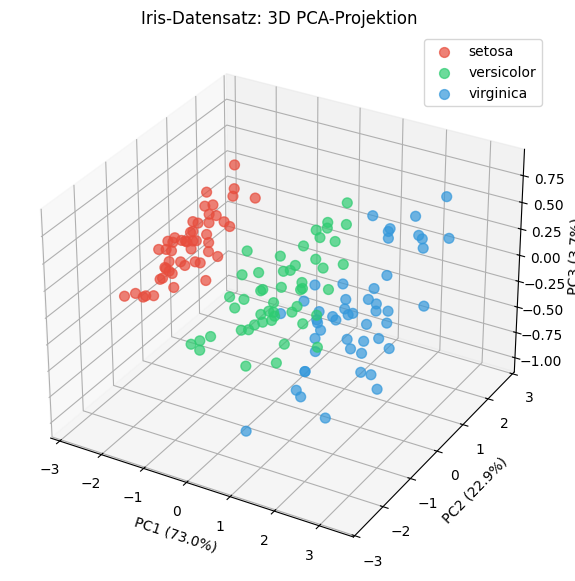

In [8]:
# Aufgabe 2: PCA mit n_components=3
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_std)

print(f"Kumulierte Varianz mit 3 Komponenten: {np.sum(pca_3d.explained_variance_ratio_)*100:.2f}%")

# 3D-Scatterplot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

colors = ['#e74c3c', '#2ecc71', '#3498db']
for label, color, name in zip([0, 1, 2], colors, target_names):
    ax.scatter(X_pca_3d[y == label, 0],
               X_pca_3d[y == label, 1],
               X_pca_3d[y == label, 2],
               label=name, color=color, alpha=0.7, s=50)

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
ax.set_title('Iris-Datensatz: 3D PCA-Projektion')
ax.legend()
plt.show()


**Erwartetes Ergebnis:**  
Die dritte Komponente erklärt nur ~3,69% zusätzliche Varianz (kumuliert: ~99,5%). Für eine 2D-Visualisierung ist sie nicht nutzbar, aber für eine 3D-Visualisierung kann sie die Trennung von Versicolor und Virginica minimal verbessern. Für die meisten Anwendungen reichen 2 Komponenten.


In [9]:
# Aufgabe 3: Automatische Komponentenwahl mit n_components=0.95

pca_auto = PCA(n_components=0.95)  # automatisch: so viele wie für 95% nötig
pca_auto.fit(X_std)

print(f"n_components_ = {pca_auto.n_components_}")
print(f"Tatsächliche kumulierte Varianz: {np.sum(pca_auto.explained_variance_ratio_)*100:.2f}%")

n_components_ = 2
Tatsächliche kumulierte Varianz: 95.81%


**Erwartetes Ergebnis:**  
`n_components_ = 2` (da 2 Komponenten bereits 95,81% erklären, was über dem Schwellwert von 95% liegt). scikit-learn wählt die **minimale Anzahl**, um den gewünschten Varianzanteil zu überschreiten.
